# Benchmark de compression sur patches 256×256 (dataset HF)

Dataset source : [nathbns/SVS-TCGA-BR](https://huggingface.co/datasets/nathbns/SVS-TCGA-BR)

Objectif : comparer plusieurs niveaux de compression JPEG sur des patches histopathologiques réels, et mesurer le compromis taille / qualité.

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import io

from datasets import load_dataset
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Paramètres
HF_REPO = "nathbns/SVS-TCGA-BR"
SPLIT = "train"
N_SAMPLES = None  # nombre de patches à tester (None = tout le split)
SEED = 42

# Niveaux de qualité JPEG à tester
JPEG_QUALITIES = [95, 85, 75, 65, 55, 45, 35]

print("Chargement du dataset...")
ds = load_dataset(HF_REPO, split=SPLIT)
print(f"Total échantillons dans {SPLIT}: {len(ds)}")


Chargement du dataset...
Total échantillons dans train: 26846


## Fonction de benchmark

Pour chaque patch :
1. Sauvegarde en PNG (référence sans perte)
2. Compression JPEG aux différentes qualités
3. Mesure : taille (Ko), SSIM, PSNR

In [9]:
def benchmark_patch(pil_img, qualities=JPEG_QUALITIES):
    """
    pil_img : PIL.Image en mode RGB
    Retourne une liste de dicts avec les résultats.
    """
    img_arr = np.array(pil_img).astype(np.float32) / 255.0
    results = []

    # Référence PNG (compressé sans perte, mais pas la source brute)
    buf_png = io.BytesIO()
    pil_img.save(buf_png, format="PNG")
    size_png_kb = len(buf_png.getvalue()) / 1024

    for q in qualities:
        buf_jpg = io.BytesIO()
        pil_img.save(buf_jpg, format="JPEG", quality=q, optimize=True)
        size_jpg_kb = len(buf_jpg.getvalue()) / 1024

        # Re-lecture pour comparaison
        rec = Image.open(buf_jpg).convert("RGB")
        rec_arr = np.array(rec).astype(np.float32) / 255.0

        s = ssim(img_arr, rec_arr, channel_axis=2, data_range=1.0)
        p = psnr(img_arr, rec_arr, data_range=1.0)

        results.append({
            "quality": q,
            "size_kb": round(size_jpg_kb, 2),
            "ratio_png": round(size_jpg_kb / size_png_kb, 3),
            "gain_pct": round((1 - size_jpg_kb / size_png_kb) * 100, 1),
            "ssim": round(s, 5),
            "psnr": round(p, 2),
        })

    return results, size_png_kb


## Exécution sur un échantillon

In [10]:
import random

random.seed(SEED)
np.random.seed(SEED)

indices = list(range(len(ds)))
random.shuffle(indices)
sample_indices = indices[:N_SAMPLES] if N_SAMPLES else indices

all_records = []
png_sizes = []

for idx in sample_indices:
    sample = ds[idx]
    img = sample["image"]
    patch_id = sample.get("patch_id", idx)
    slide_name = sample.get("slide_name", "unknown")

    res, size_png = benchmark_patch(img)
    png_sizes.append(size_png)

    for r in res:
        r["patch_id"] = patch_id
        r["slide_name"] = slide_name
        r["size_png_kb"] = round(size_png, 2)
        all_records.append(r)

df_all = pd.DataFrame(all_records)
print(f"Benchmark terminé sur {len(sample_indices)} patches.")
print(df_all.head())

Benchmark terminé sur 26846 patches.
   quality  size_kb  ratio_png  gain_pct     ssim   psnr  patch_id  \
0       95    27.78      0.229      77.1  0.91256  31.42     17684   
1       85    16.10      0.133      86.7  0.85944  29.80     17684   
2       75    12.33      0.102      89.8  0.83241  29.01     17684   
3       65    10.43      0.086      91.4  0.82164  28.65     17684   
4       55     9.08      0.075      92.5  0.81331  28.41     17684   

                                          slide_name  size_png_kb  
0  TCGA-CG-4305-01Z-00-DX1.65167641-c270-4763-8bb...       121.26  
1  TCGA-CG-4305-01Z-00-DX1.65167641-c270-4763-8bb...       121.26  
2  TCGA-CG-4305-01Z-00-DX1.65167641-c270-4763-8bb...       121.26  
3  TCGA-CG-4305-01Z-00-DX1.65167641-c270-4763-8bb...       121.26  
4  TCGA-CG-4305-01Z-00-DX1.65167641-c270-4763-8bb...       121.26  


## Résultats agrégés par qualité

In [11]:
df_agg = df_all.groupby("quality").agg(
    taille_moy_ko=("size_kb", "mean"),
    taille_std_ko=("size_kb", "std"),
    ssim_moy=("ssim", "mean"),
    ssim_std=("ssim", "std"),
    psnr_moy=("psnr", "mean"),
    psnr_std=("psnr", "std"),
    gain_moy=("gain_pct", "mean"),
).reset_index()

df_agg["taille_moy_ko"] = df_agg["taille_moy_ko"].round(1)
df_agg["taille_std_ko"] = df_agg["taille_std_ko"].round(1)
df_agg["ssim_moy"] = df_agg["ssim_moy"].round(4)
df_agg["ssim_std"] = df_agg["ssim_std"].round(4)
df_agg["psnr_moy"] = df_agg["psnr_moy"].round(2)
df_agg["psnr_std"] = df_agg["psnr_std"].round(2)
df_agg["gain_moy"] = df_agg["gain_moy"].round(1)

display(df_agg)


,quality,taille_moy_ko,taille_std_ko,ssim_moy,ssim_std,psnr_moy,psnr_std,gain_moy
0,35,7.0,1.9,0.8929,0.0313,30.61,3.04,93.8
1,45,8.1,2.2,0.9036,0.0293,31.22,3.14,92.8
2,55,9.1,2.5,0.9114,0.0280,31.69,3.19,92.0
3,65,10.5,2.8,0.9192,0.0267,32.22,3.30,90.8
4,75,12.4,3.3,0.9278,0.0252,32.89,3.52,89.0
5,85,16.3,4.2,0.9402,0.0223,33.98,3.73,85.6
6,95,28.8,7.1,0.9664,0.0142,36.86,3.75,74.2


## Graphiques

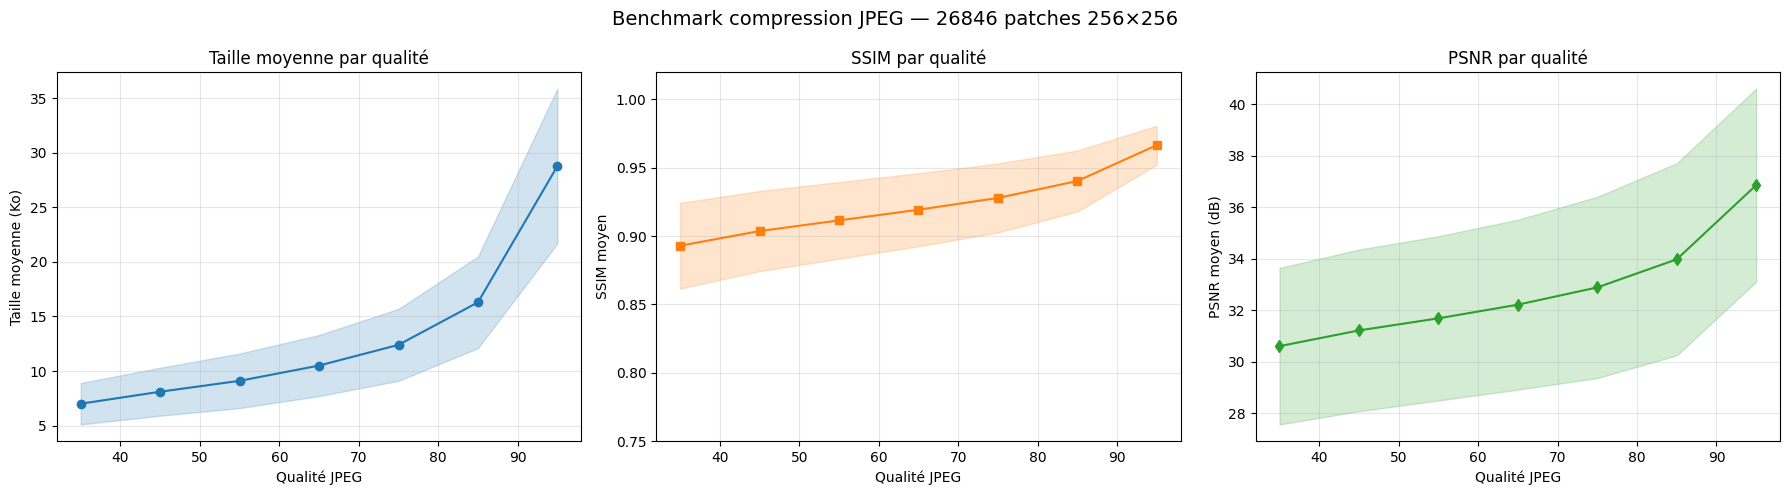

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Taille vs Qualité
ax = axes[0]
ax.plot(df_agg["quality"], df_agg["taille_moy_ko"], "o-", color="tab:blue")
ax.fill_between(
    df_agg["quality"],
    df_agg["taille_moy_ko"] - df_agg["taille_std_ko"],
    df_agg["taille_moy_ko"] + df_agg["taille_std_ko"],
    alpha=0.2, color="tab:blue"
)
ax.set_xlabel("Qualité JPEG")
ax.set_ylabel("Taille moyenne (Ko)")
ax.set_title("Taille moyenne par qualité")
ax.grid(True, alpha=0.3)

# 2) SSIM vs Qualité
ax = axes[1]
ax.plot(df_agg["quality"], df_agg["ssim_moy"], "s-", color="tab:orange")
ax.fill_between(
    df_agg["quality"],
    df_agg["ssim_moy"] - df_agg["ssim_std"],
    df_agg["ssim_moy"] + df_agg["ssim_std"],
    alpha=0.2, color="tab:orange"
)
ax.set_xlabel("Qualité JPEG")
ax.set_ylabel("SSIM moyen")
ax.set_title("SSIM par qualité")
ax.set_ylim(0.75, 1.02)
ax.grid(True, alpha=0.3)

# 3) PSNR vs Qualité
ax = axes[2]
ax.plot(df_agg["quality"], df_agg["psnr_moy"], "d-", color="tab:green")
ax.fill_between(
    df_agg["quality"],
    df_agg["psnr_moy"] - df_agg["psnr_std"],
    df_agg["psnr_moy"] + df_agg["psnr_std"],
    alpha=0.2, color="tab:green"
)
ax.set_xlabel("Qualité JPEG")
ax.set_ylabel("PSNR moyen (dB)")
ax.set_title("PSNR par qualité")
ax.grid(True, alpha=0.3)

plt.suptitle(f"Benchmark compression JPEG — {len(sample_indices)} patches 256×256", fontsize=14)
plt.tight_layout()
plt.show()

## Comparaison visuelle (exemples)

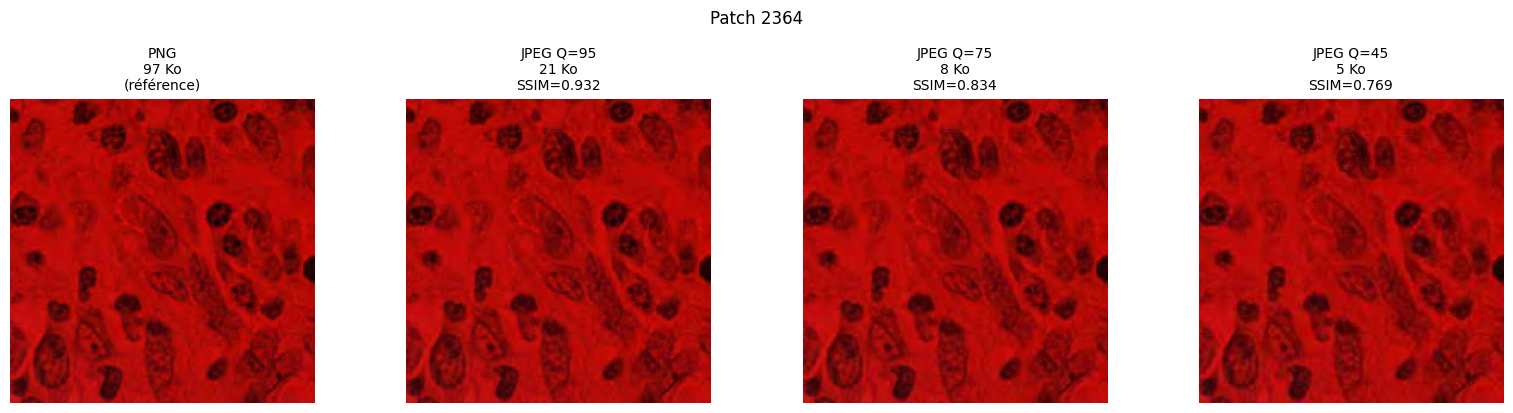

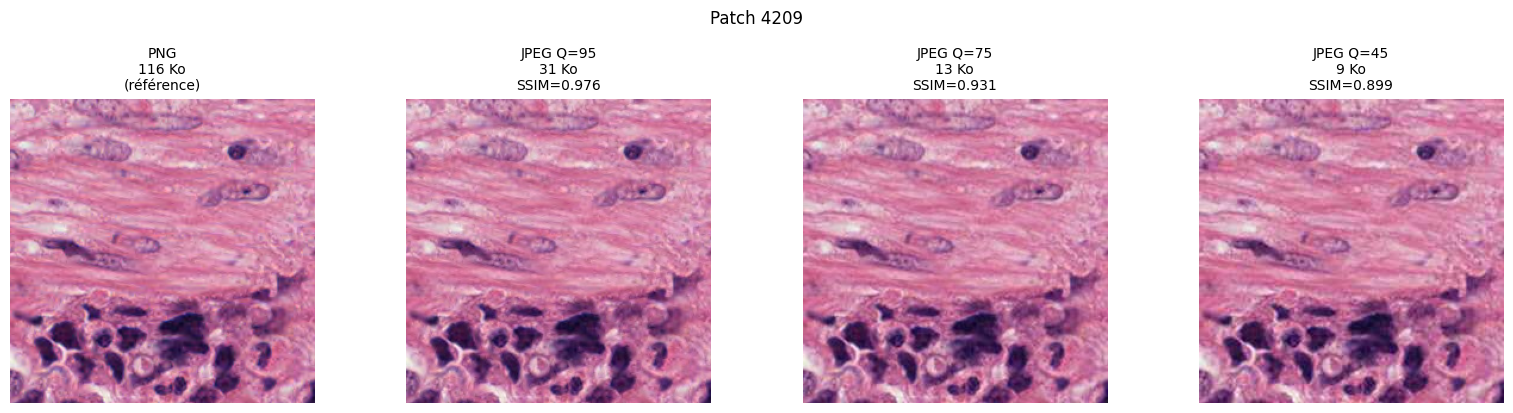

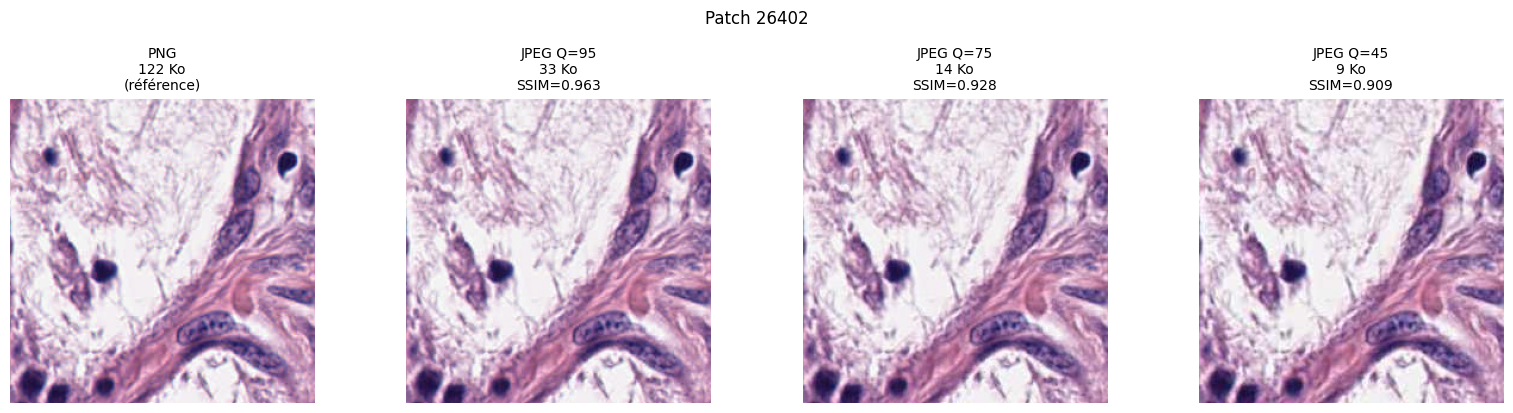

In [13]:
# On prend 3 patches au hasard pour la comparaison visuelle
viz_indices = random.sample(sample_indices, 3)
qualities_viz = [95, 75, 45]

for idx in viz_indices:
    sample = ds[idx]
    img = sample["image"]
    patch_id = sample.get("patch_id", idx)

    n_cols = 1 + len(qualities_viz)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4))

    # Original (PNG)
    buf_png = io.BytesIO()
    img.save(buf_png, format="PNG")
    size_png = len(buf_png.getvalue()) / 1024
    axes[0].imshow(img)
    axes[0].set_title(f"PNG\n{size_png:.0f} Ko\n(référence)", fontsize=10)
    axes[0].axis("off")

    # JPEG compressés
    for ax, q in zip(axes[1:], qualities_viz):
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q, optimize=True)
        rec = Image.open(buf).convert("RGB")
        size_jpg = len(buf.getvalue()) / 1024

        # Récupère métriques depuis df_all
        row = df_all[(df_all["patch_id"] == patch_id) & (df_all["quality"] == q)].iloc[0]

        ax.imshow(rec)
        ax.set_title(f"JPEG Q={q}\n{size_jpg:.0f} Ko\nSSIM={row['ssim']:.3f}", fontsize=10)
        ax.axis("off")

    plt.suptitle(f"Patch {patch_id}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.show()

## Sauvegarde des résultats

In [ ]:
OUT_DIR = Path("./benchmark_results")
OUT_DIR.mkdir(exist_ok=True)

# Sauvegarde CSV
df_all.to_csv(OUT_DIR / "benchmark_compression_detail.csv", index=False)
df_agg.to_csv(OUT_DIR / "benchmark_compression_agreg.csv", index=False)

Résultats sauvegardés dans : benchmark_results
- benchmark_compression_detail.csv (résultats patch par patch)
- benchmark_compression_agreg.csv (moyennes par qualité)
